# Interval training analysis

Interactive walk-through of the pipeline in `intervals.py` and `charts.py`. For a one-shot run on any GPX use `python run.py data/<file>.gpx`, which also builds the 3D viewer.

Change `GPX_FILE` below to look at another export.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from intervals import read_gpx, add_pace, detect_intervals, label_phases, summarize, recoveries, fmt_pace
import charts

GPX_FILE = Path("data/3_x_5min.gpx")
SMOOTH_S = 15          # speed smoothing window
MIN_WORK_S = 120       # a rep must last at least this long
MAX_GAP_S = 20         # dips shorter than this inside a rep are bridged
CADENCE_FACTOR = 2     # Garmin writes strides per leg; 2 gives steps/min

## 1. Parse and derive pace

In [2]:
df, name = read_gpx(GPX_FILE)
df = add_pace(df, smooth_s=SMOOTH_S, cadence_factor=CADENCE_FACTOR)
total_km = df.dist_m.iloc[-1] / 1000
print(f"{name}: {len(df)} points, {total_km:.2f} km in {fmt_pace(df.t.iloc[-1] / 60)}, "
      f"average {fmt_pace(df.t.iloc[-1] / 60 / total_km)} /km, started {df.time.iloc[0]:%Y-%m-%d %H:%M} UTC")
df.head()

3 x 5min: 1983 points, 5.63 km in 33:10, average 5:54 /km, started 2026-09-08 18:37 UTC


,time,lat,lon,ele,cadence,hr,t,dist_m,speed_raw,speed,pace_min_km,cadence_spm
0,2026-09-08 18:37:27+00:00,51.047585,3.712648,8.3,0.0,NaN,0.0,0.000000,0.000000,2.225954,7.487425,0.0
1,2026-09-08 18:37:28+00:00,51.047596,3.712610,8.3,0.0,NaN,1.0,2.924479,2.924479,2.207242,7.550900,0.0
2,2026-09-08 18:37:29+00:00,51.047607,3.712570,8.3,69.0,NaN,2.0,5.976513,3.052034,2.363134,7.052781,138.0
3,2026-09-08 18:37:31+00:00,51.047628,3.712531,8.3,69.0,NaN,4.0,9.566141,1.794814,2.404048,6.932750,138.0
4,2026-09-08 18:37:32+00:00,51.047643,3.712514,8.3,69.0,NaN,5.0,11.614126,2.047985,2.489794,6.693994,138.0


## 2. Detect the intervals

The smoothed speed is bimodal (hard running vs. easy running and walking). A two-means split places the threshold between the modes; every stretch above it that lasts at least `MIN_WORK_S` is a work interval.

In [3]:
intervals = detect_intervals(df, min_work_s=MIN_WORK_S, max_gap_s=MAX_GAP_S)
df = label_phases(df, intervals)
thr = intervals.attrs["threshold"]
print(f"Speed threshold: {thr:.2f} m/s ({fmt_pace(1000 / thr / 60)} /km), {len(intervals)} work intervals")
summarize(intervals)

Speed threshold: 2.86 m/s (5:49 /km), 3 work intervals


,start,duration,distance_km,pace,cadence_spm,elev_gain_m
Rep 1,12:45,4:55,1.130,4:21,145,1.9
Rep 2,20:02,5:10,1.175,4:24,144,0.7
Rep 3,27:28,5:27,1.266,4:18,146,0.9


### Recovery between the reps

In [4]:
recoveries(df, intervals)

,duration,distance_m,pace
between,,,
Rep 1 -> Rep 2,2:22,211,11:12
Rep 2 -> Rep 3,2:16,206,11:00


## 3. Visualize

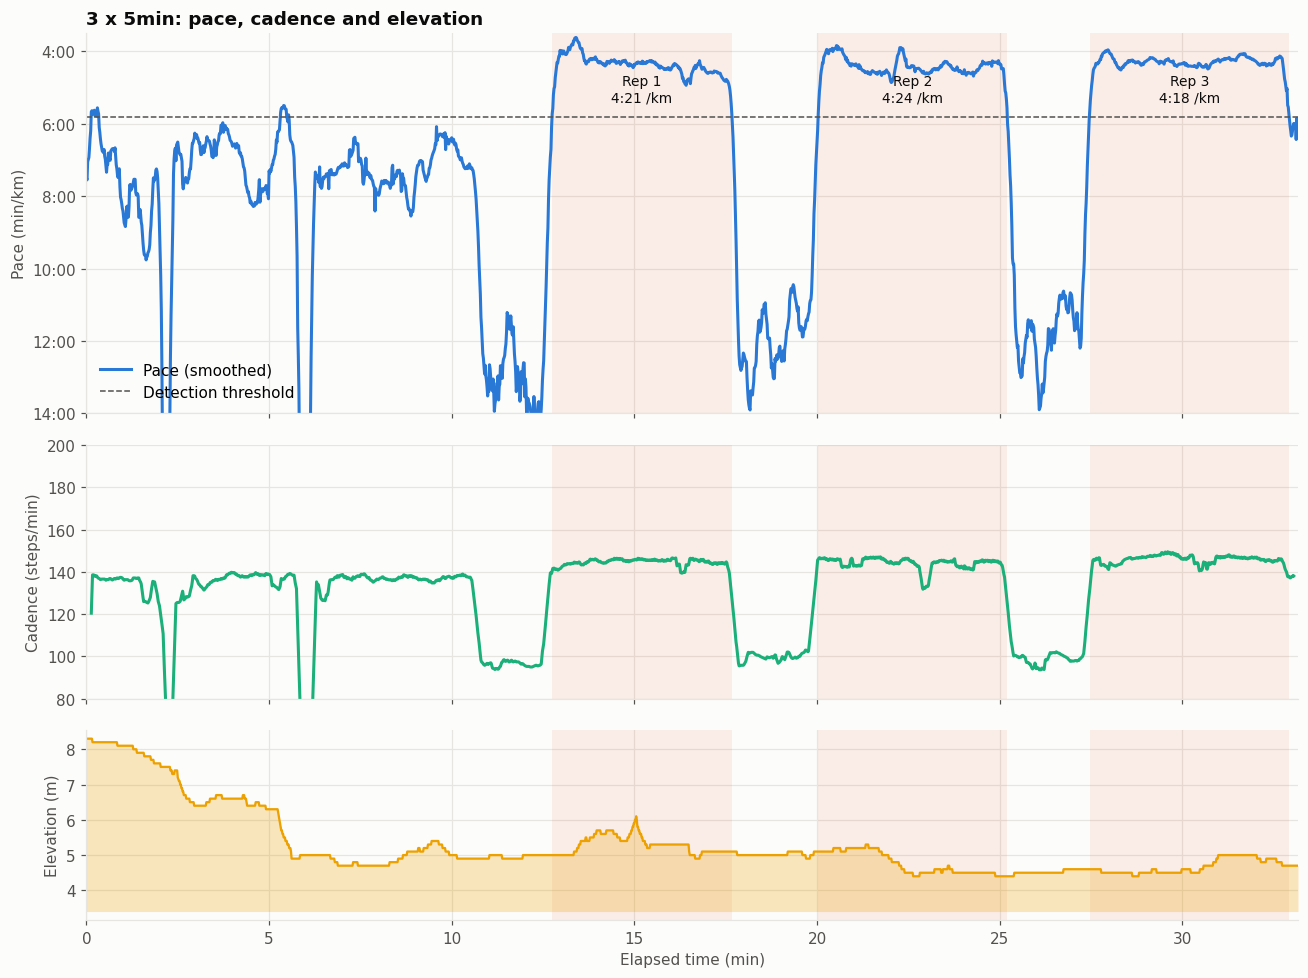

In [5]:
charts.overview(df, intervals, name); plt.show()

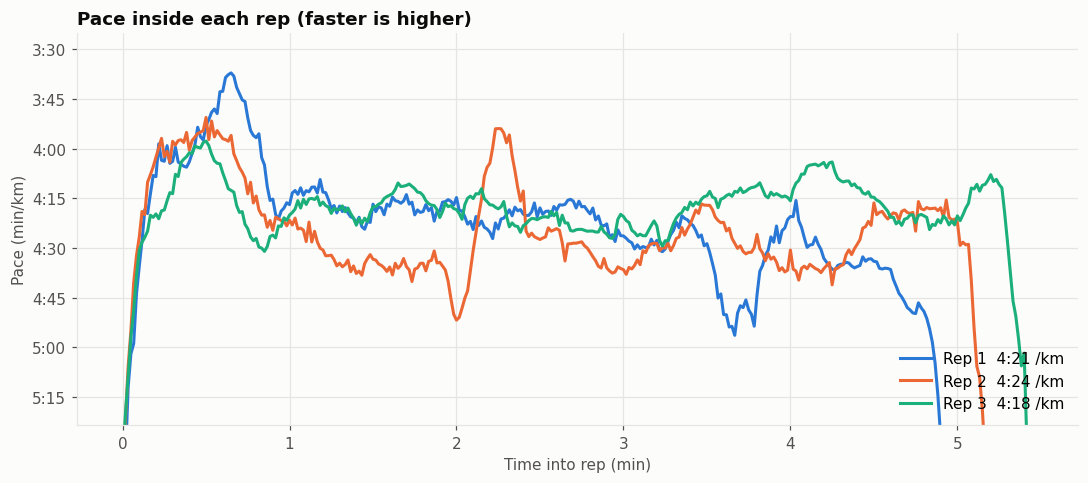

In [6]:
charts.rep_pace(df, intervals); plt.show()

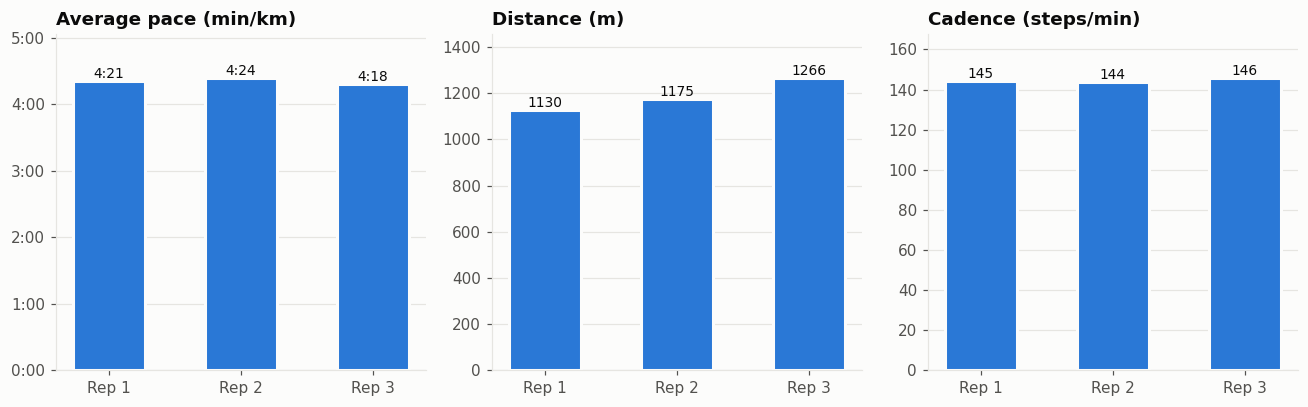

In [7]:
charts.rep_summary(intervals); plt.show()

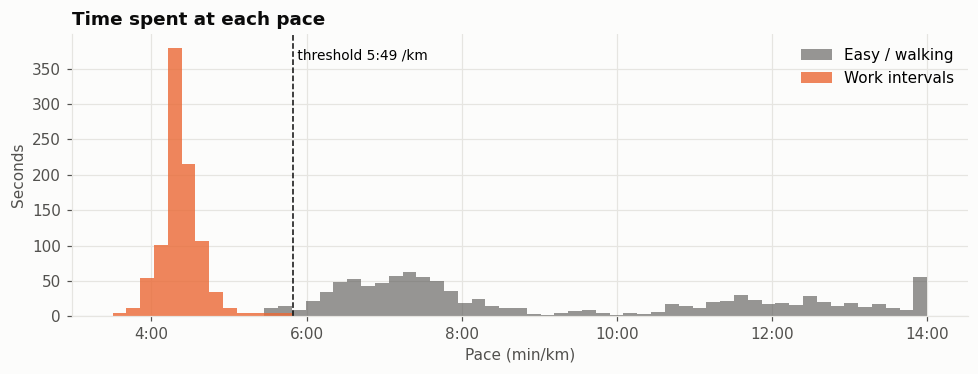

In [8]:
charts.pace_histogram(df, intervals); plt.show()

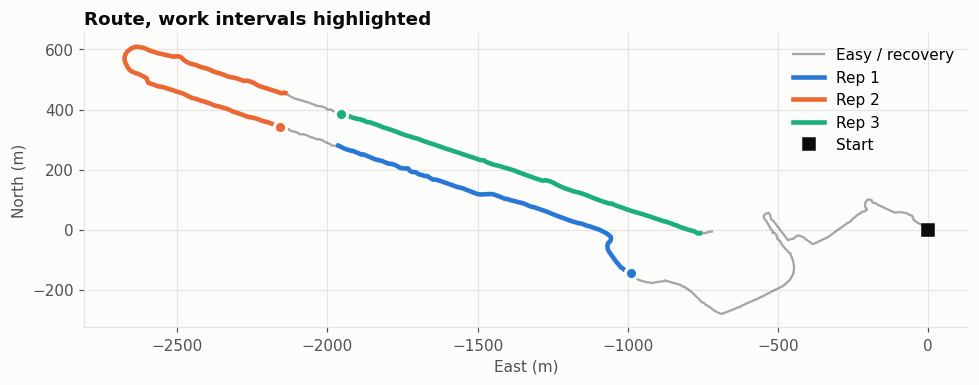

In [9]:
charts.route(df, intervals); plt.show()

## 4. 3D viewer

`python run.py data/<file>.gpx` writes the CSVs, these charts and the three.js viewer (`index.html` + `data.js` in the repo root). From here you can do the same:

In [10]:
# from viewer import build_viewer
# build_viewer(df, intervals, name, Path("."), with_map=True)